In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle
import numpy as np
import os

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.8.0


In [4]:
DATA_DIR = 'dataset'
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.0001

train_dir = os.path.join(DATA_DIR, 'train')
valid_dir = os.path.join(DATA_DIR, 'valid')
test_dir = os.path.join(DATA_DIR, 'test')

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

valid_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_data = datasets.ImageFolder(valid_dir, transform=valid_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=valid_test_transforms)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

class_names = train_data.classes
print(f"Classes found: {class_names}")

Classes found: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [7]:
from torchsummary import summary

model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(class_names))
)

model = model.to(device)

In [8]:
params_to_update = [
    {'params': model.layer4.parameters(), 'lr': 0.00001},
    {'params': model.fc.parameters(), 'lr': LEARNING_RATE}
]

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params_to_update)

print("Optimizer configured with different learning rates for ResNet fine-tuning.")

Optimizer configured with different learning rates for ResNet fine-tuning.


In [10]:
valid_loss_min = np.inf

for epoch in range(1, EPOCHS + 1):
    train_loss = 0.0
    valid_loss = 0.0

    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    model.eval()
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            valid_loss += loss.item() * images.size(0)
            
    train_loss = train_loss / len(train_loader.dataset)
    valid_loss = valid_loss / len(valid_loader.dataset)
        
    print(f'Epoch: {epoch} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {valid_loss:.6f}')

    if valid_loss <= valid_loss_min:
        print('Validation loss decreased. Saving model...')
        torch.save(model.state_dict(), 'best_resnet_model.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 1.285633 	Validation Loss: 1.264021
Validation loss decreased. Saving model...
Epoch: 2 	Training Loss: 1.032594 	Validation Loss: 1.062958
Validation loss decreased. Saving model...
Epoch: 3 	Training Loss: 0.895481 	Validation Loss: 0.954140
Validation loss decreased. Saving model...
Epoch: 4 	Training Loss: 0.846881 	Validation Loss: 0.965530
Epoch: 5 	Training Loss: 0.731502 	Validation Loss: 0.833594
Validation loss decreased. Saving model...
Epoch: 6 	Training Loss: 0.657663 	Validation Loss: 0.771320
Validation loss decreased. Saving model...
Epoch: 7 	Training Loss: 0.569765 	Validation Loss: 0.739571
Validation loss decreased. Saving model...
Epoch: 8 	Training Loss: 0.498711 	Validation Loss: 0.667505
Validation loss decreased. Saving model...
Epoch: 9 	Training Loss: 0.401741 	Validation Loss: 0.681583
Epoch: 10 	Training Loss: 0.353093 	Validation Loss: 0.618477
Validation loss decreased. Saving model...
Epoch: 11 	Training Loss: 0.301147 	Validatio

In [11]:
model.load_state_dict(torch.load('best_resnet_model.pt'))
model.to(device)

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(f"\nTest Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Test Accuracy: 81.27%

Classification Report:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.85      0.70      0.77       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.88      0.75      0.81        51
                                          normal       1.00      1.00      1.00        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.67      0.89      0.77        90

                                        accuracy                           0.81       315
                                       macro avg       0.85      0.83      0.84       315
                                    weighted avg       0.83      0.81      0.81       315



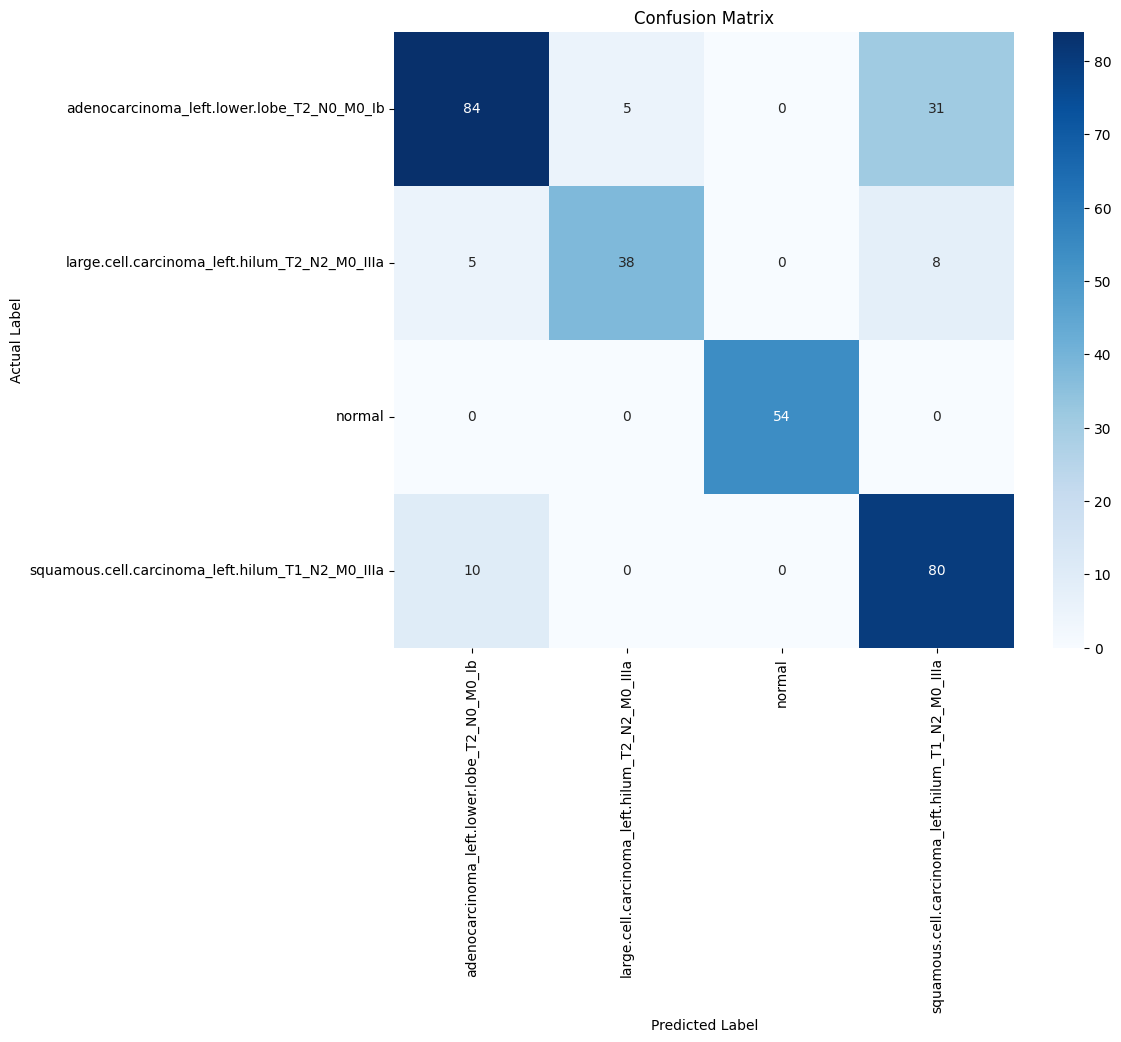

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

--- Specificity ---
Specificity for adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 0.9231
Specificity for large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 0.9811
Specificity for normal: 1.0000
Specificity for squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 0.8267

--- Overall Performance Metrics ---
Cohen's Kappa: 0.7402
Matthews Correlation Coefficient (MCC): 0.7472

Weighted Average AUC Score (One-vs-Rest): 0.9458



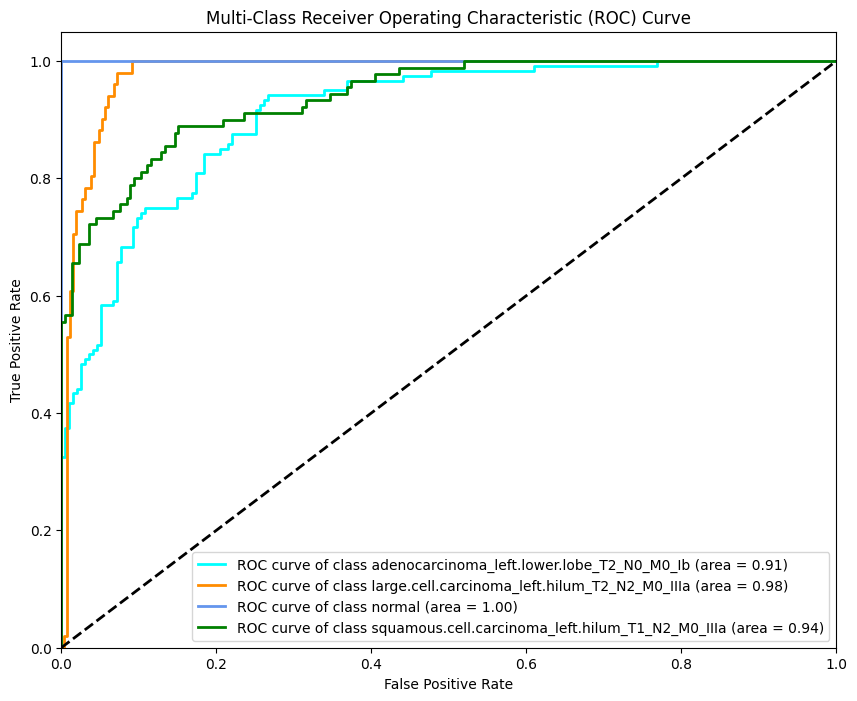

In [13]:
# --- 1. Calculate Specificity from the Confusion Matrix ---
print("--- Specificity ---")
for i, class_name in enumerate(class_names):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity = tn / (tn + fp)
    print(f'Specificity for {class_name}: {specificity:.4f}')

# --- 2. Calculate Cohen's Kappa and MCC ---
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
print("\n--- Overall Performance Metrics ---")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# --- 3. Calculate AUC-ROC Score and Plot the Curve ---
y_prob = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        # Apply softmax to get probabilities
        probabilities = F.softmax(outputs, dim=1)
        y_prob.extend(probabilities.cpu().numpy())

y_prob = np.array(y_prob)
# Binarize the true labels for multi-class ROC calculation
y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))

# Calculate the AUC score
auc_score = roc_auc_score(y_true_binarized, y_prob, multi_class='ovr', average='weighted')
print(f"\nWeighted Average AUC Score (One-vs-Rest): {auc_score:.4f}\n")

# --- Plotting the ROC Curve for each class ---
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])

for i, color in zip(range(len(class_names)), colors):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
    roc_auc[i] = roc_auc_score(y_true_binarized[:, i], y_prob[:, i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()